In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/E-commerce Customer Behavior - Sheet1.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (350, 11)

Columns:
 ['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Data Cleansing
# Drop Customer ID
df = df.drop(columns=['Customer ID'])

# Convert Gender: Male -> 1, Female -> 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Convert Membership Type: Gold -> 3, Silver -> 2, Bronze -> 1
df['Membership Type'] = df['Membership Type'].map({'Gold': 3, 'Silver': 2, 'Bronze': 1})

# Convert Satisfaction Level: Satisfied -> 2, Neutral -> 1, Unsatisfied -> 0
df['Satisfaction Level'] = df['Satisfaction Level'].map({'Satisfied': 2, 'Neutral': 1, 'Unsatisfied': 0})

# Convert Discount Applied: True -> 1, False -> 0
df['Discount Applied'] = df['Discount Applied'].astype(int)

# Convert City to dummy variables (one-hot encoding)
city_dummies = pd.get_dummies(df['City'], prefix='City', drop_first=True)
df = pd.concat([df.drop(columns=['City']), city_dummies], axis=1)

# Drop missing values
df.dropna(inplace=True)

print("\nCleaned shape:", df.shape)
print("\nAll columns after conversion:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())


Cleaned shape: (348, 14)

All columns after conversion:
 ['Gender', 'Age', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco']

Data types:
 Gender                        int64
Age                           int64
Membership Type               int64
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied              int64
Days Since Last Purchase      int64
Satisfaction Level          float64
City_Houston                   bool
City_Los Angeles               bool
City_Miami                     bool
City_New York                  bool
City_San Francisco             bool
dtype: object

First 5 rows:
    Gender  Age  Membership Type  Total Spend  Items Purchased  Average Rating  \
0       0   29                3      1120.20               14    


=== Summary Statistics ===
       Total Spend     Age  Items Purchased  Average Rating  \
count       348.00  348.00           348.00          348.00   
mean        847.79   33.58            12.63            4.02   
std         361.69    4.88             4.15            0.58   
min         410.80   26.00             7.00            3.00   
25%         505.75   30.00             9.00            3.50   
50%         780.20   32.00            12.00            4.10   
75%        1160.60   37.00            15.00            4.50   
max        1520.10   43.00            21.00            4.90   

       Days Since Last Purchase  
count                    348.00  
mean                      26.61  
std                       13.47  
min                        9.00  
25%                       15.00  
50%                       23.00  
75%                       38.00  
max                       63.00  


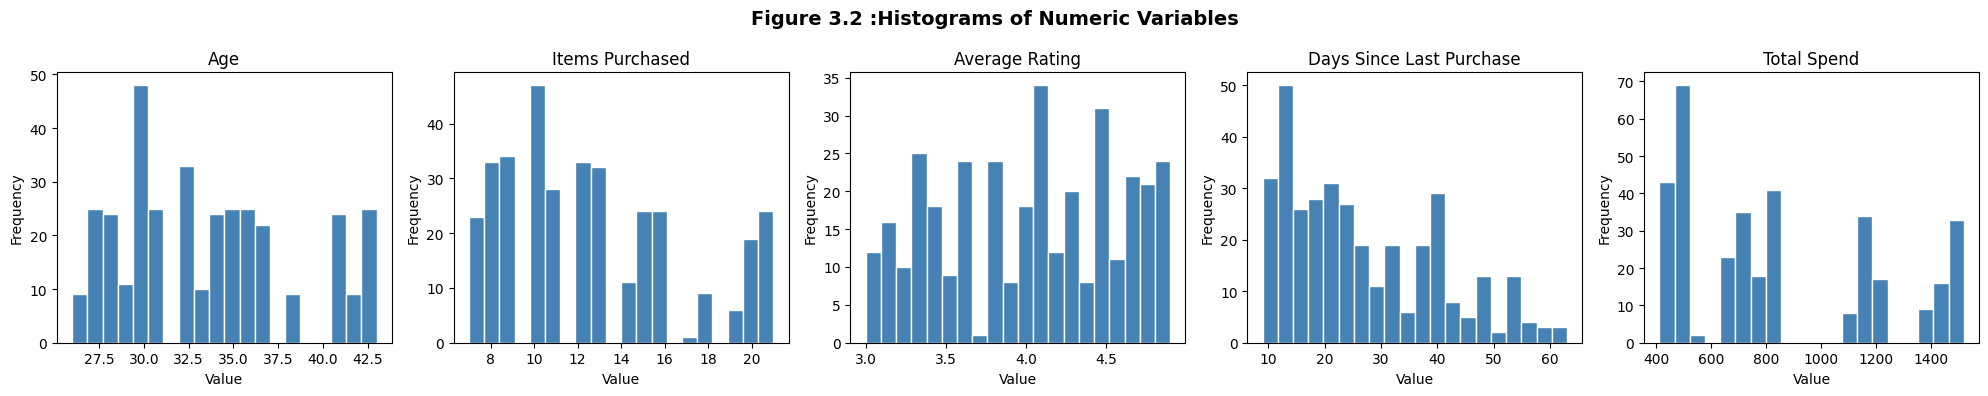

Saved: histograms.png


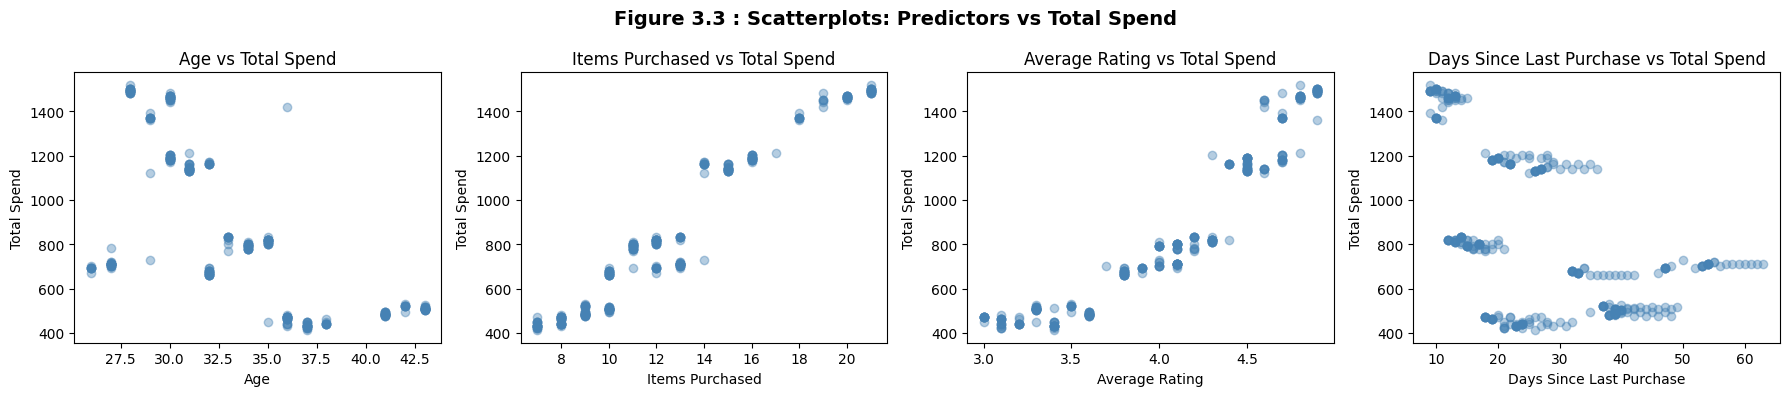

Saved: scatterplots.png


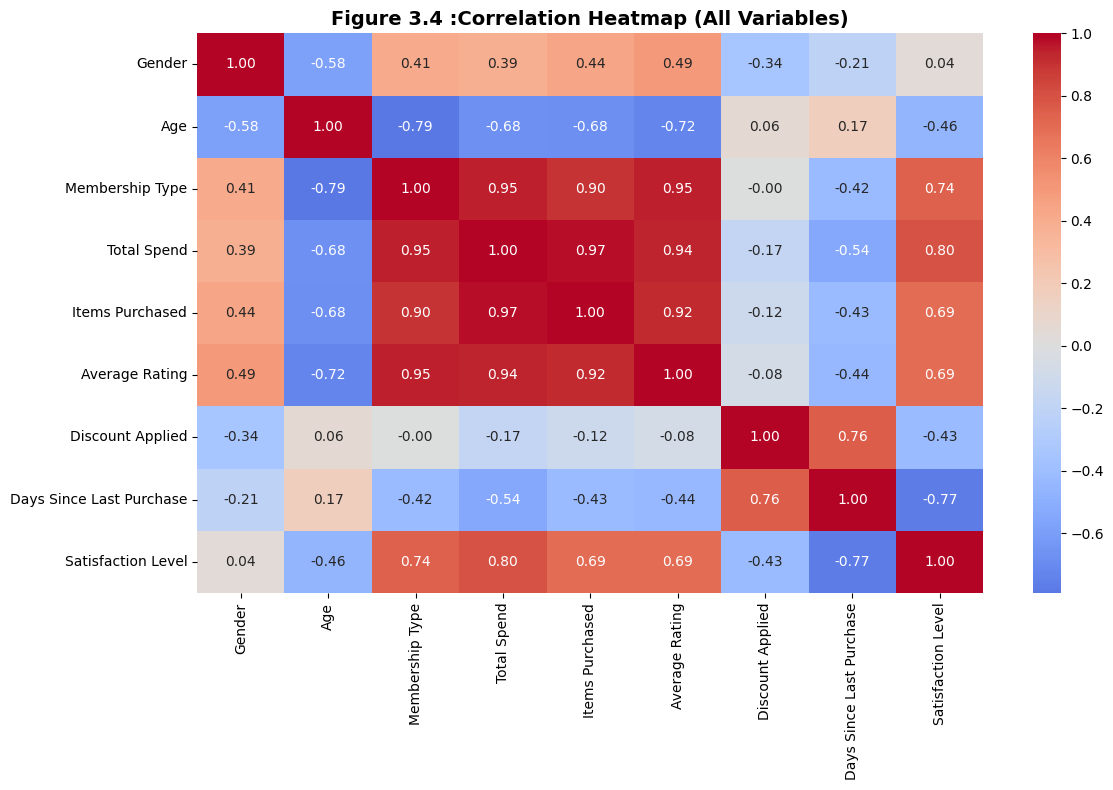

Saved: correlation_heatmap.png


In [8]:
#EXPLORATORY DATA ANALYSIS (EDA)
# --- Summary Statistics ---
numeric_cols = ['Total Spend', 'Age', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

print("\n=== Summary Statistics ===")
print(df[numeric_cols].describe().round(2))

# --- Histograms (numeric columns only) ---
numeric_cols = ['Age', 'Items Purchased', 'Average Rating',
                'Days Since Last Purchase', 'Total Spend']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
plt.suptitle('Figure 3.2 :Histograms of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150)
plt.show()
print("Saved: histograms.png")

# --- Scatterplots (X vs Y) ---
X_vars = ['Age', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(X_vars):
    axes[i].scatter(df[col], df['Total Spend'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Total Spend')
    axes[i].set_title(f'{col} vs Total Spend')
plt.suptitle('Figure 3.3 : Scatterplots: Predictors vs Total Spend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatterplots.png', dpi=150)
plt.show()
print("Saved: scatterplots.png")

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Figure 3.4 :Correlation Heatmap (All Variables)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

In [9]:
# INFERENCE COMPONENT — Hypothesis Testing
r, p_value = stats.pearsonr(df['Items Purchased'], df['Total Spend'])

print("\n=== Hypothesis Test: Pearson Correlation ===")
print(f"H0: No correlation between Items Purchased and Total Spend (r = 0)")
print(f"H1: Significant correlation exists (r ≠ 0)")
print(f"Pearson r  = {r:.4f}")
print(f"p-value    = {p_value:.4f}")
if p_value < 0.05:
    print("Result: Reject H0 → Significant correlation at α = 0.05")
else:
    print("Result: Fail to reject H0 → No significant correlation at α = 0.05")

# --- 95% Confidence Interval for Mean Total Spend ---
mean_spend = df['Total Spend'].mean()
se = stats.sem(df['Total Spend'])
ci = stats.t.interval(0.95, df=len(df)-1, loc=mean_spend, scale=se)

print("\n=== 95% Confidence Interval for Mean Total Spend ===")
print(f"{'Statistic':<25} {'Value':>10}")
print("-" * 37)
print(f"{'Sample Mean':<25} {'$'+f'{mean_spend:.2f}':>10}")
print(f"{'Standard Error':<25} {'$'+f'{se:.2f}':>10}")
print(f"{'95% CI Lower Bound':<25} {'$'+f'{ci[0]:.2f}':>10}")
print(f"{'95% CI Upper Bound':<25} {'$'+f'{ci[1]:.2f}':>10}")


=== Hypothesis Test: Pearson Correlation ===
H0: No correlation between Items Purchased and Total Spend (r = 0)
H1: Significant correlation exists (r ≠ 0)
Pearson r  = 0.9723
p-value    = 0.0000
Result: Reject H0 → Significant correlation at α = 0.05

=== 95% Confidence Interval for Mean Total Spend ===
Statistic                      Value
-------------------------------------
Sample Mean                  $847.79
Standard Error                $19.39
95% CI Lower Bound           $809.66
95% CI Upper Bound           $885.93



=== Simple Linear Regression ===
                            OLS Regression Results                            
Dep. Variable:            Total Spend   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     5982.
Date:                Fri, 01 May 2026   Prob (F-statistic):          1.94e-220
Time:                        12:32:31   Log-Likelihood:                -2037.6
No. Observations:                 348   AIC:                             4079.
Df Residuals:                     346   BIC:                             4087.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const   

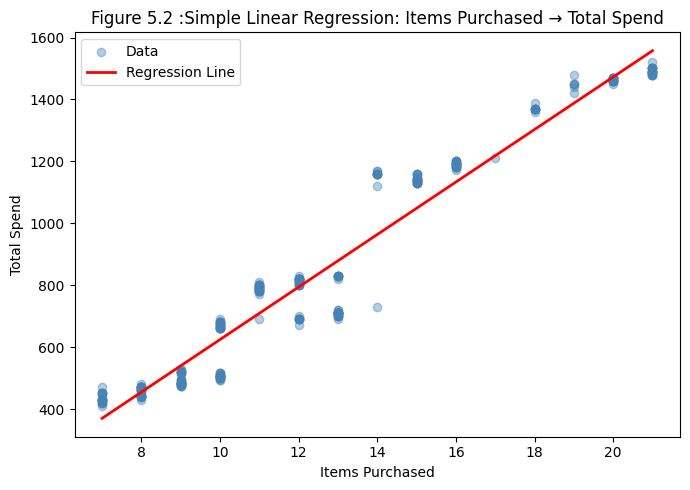

Saved: simple_regression.png


In [10]:
#SIMPLE LINEAR REGRESSION
X_simple = sm.add_constant(df['Items Purchased'])
model_simple = sm.OLS(df['Total Spend'], X_simple).fit()

print("\n=== Simple Linear Regression ===")
print(model_simple.summary())

# Plot regression line
plt.figure(figsize=(7, 5))
plt.scatter(df['Items Purchased'], df['Total Spend'], alpha=0.4, color='steelblue', label='Data')
x_line = np.linspace(df['Items Purchased'].min(), df['Items Purchased'].max(), 100)
y_line = model_simple.params['const'] + model_simple.params['Items Purchased'] * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Items Purchased')
plt.ylabel('Total Spend')
plt.title('Figure 5.2 :Simple Linear Regression: Items Purchased → Total Spend')
plt.legend()
plt.tight_layout()
plt.savefig('simple_regression.png', dpi=150)
plt.show()
print("Saved: simple_regression.png")

In [12]:

# 6. MULTIPLE LINEAR REGRESSION  (FIXED — multicollinearity diagnosis)
X_cols_full = [c for c in df.columns if c != 'Total Spend']
for c in X_cols_full:
    if df[c].dtype == 'bool':
        df[c] = df[c].astype(int)
    df[c] = pd.to_numeric(df[c], errors='coerce')
#response is numeric
df['Total Spend'] = pd.to_numeric(df['Total Spend'], errors='coerce')
#Drop any rows that became NaN
df = df.dropna(subset=X_cols_full + ['Total Spend']).reset_index(drop=True)

#int/float
print("Dtypes before fitting:")
print(df[X_cols_full + ['Total Spend']].dtypes)

# Initial full model + VIF
X_full = sm.add_constant(df[X_cols_full].astype(float))
model_full = sm.OLS(df['Total Spend'].astype(float), X_full).fit()

print("\n=== Initial Multiple Regression (ALL variables) ===")
print(model_full.summary())

def compute_vif(X_design, predictors):
    """Compute VIF for each predictor in a design matrix that already has a constant."""
    vif = pd.DataFrame()
    vif['Variable'] = predictors
    vif['VIF'] = [variance_inflation_factor(X_design.values, i + 1)
                  for i in range(len(predictors))]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_initial = compute_vif(X_full, X_cols_full)
print("\n=== VIF — BEFORE Fix (diagnosing multicollinearity) ===")
print(vif_initial.to_string(index=False))
print("\nDiagnosis: VIF values that are extremely large (or 'inf') indicate")
print("that a variable is a near-perfect linear function of the others.")
print("In this dataset, Membership Type, Discount Applied, and Satisfaction")
print("Level are deterministically linked (e.g., every Bronze member has a")
print("discount applied and is Unsatisfied), so they encode the same info.")

# Iteratively drop the highest-VIF variable until all VIF < 5
threshold = 5
X_cols_reduced = X_cols_full.copy()
dropped = []

while True:
    X_design = sm.add_constant(df[X_cols_reduced].astype(float))
    vif_df = compute_vif(X_design, X_cols_reduced)
    max_vif = vif_df['VIF'].max()
    if max_vif < threshold or len(X_cols_reduced) <= 1:
        break
    worst = vif_df.iloc[0]['Variable']
    dropped.append((worst, round(max_vif, 2)))
    X_cols_reduced.remove(worst)

print("\n=== VIF Reduction Procedure ===")
if dropped:
    for var, v in dropped:
        print(f"  Dropped '{var}' (VIF = {v})")
else:
    print("  No variables needed to be dropped.")

# Refit the multiple regression on the reduced predictor set
X_reduced = sm.add_constant(df[X_cols_reduced].astype(float))
model_multi = sm.OLS(df['Total Spend'].astype(float), X_reduced).fit()

print("\n=== Multiple Linear Regression (AFTER VIF Fix) ===")
print(model_multi.summary())

vif_final = compute_vif(X_reduced, X_cols_reduced)
print("\n=== VIF — AFTER Fix (all values should be < 5) ===")
print(vif_final.to_string(index=False))


Dtypes before fitting:
Gender                        int64
Age                           int64
Membership Type               int64
Items Purchased               int64
Average Rating              float64
Discount Applied              int64
Days Since Last Purchase      int64
Satisfaction Level          float64
City_Houston                  int64
City_Los Angeles              int64
City_Miami                    int64
City_New York                 int64
City_San Francisco            int64
Total Spend                 float64
dtype: object

=== Initial Multiple Regression (ALL variables) ===
                            OLS Regression Results                            
Dep. Variable:            Total Spend   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.935e+04
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:      


=== Model Comparison ===
Simple Regression       — R^2: 0.9453 | Adj R^2: 0.9452
Multiple Regression     — R^2: 0.9907 | Adj R^2: 0.9906
Variables retained in multiple model: ['Age', 'Days Since Last Purchase', 'City_Houston', 'City_New York', 'City_San Francisco']


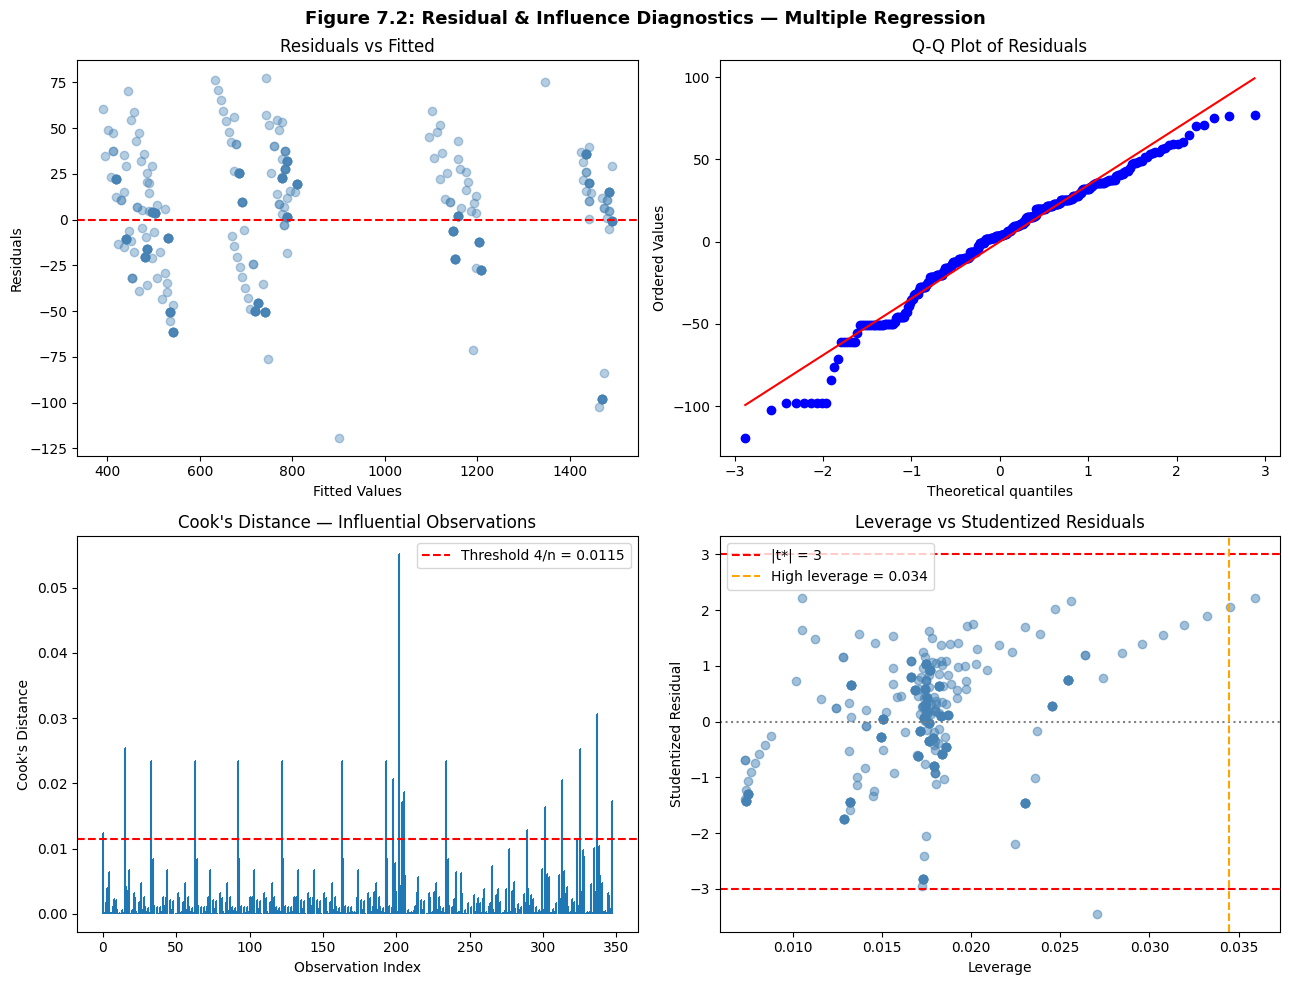

Saved: residual_analysis.png

=== Outlier & Influence Investigation ===
n = 348, predictors k = 5
Cook's Distance threshold (4/n) : 0.0115
High leverage threshold (2(k+1)/n): 0.0345
# influential points (Cook's D)  : 19
# high-leverage points           : 2
# studentized residual outliers  : 1

Top influential observations (up to 10):
 Index  Cook's D  Leverage  Stud. Resid.  Total Spend  Items Purchased  Avg Rating
   202    0.0551    0.0271       -3.4483        780.9               11         4.2
   337    0.0306    0.0359        2.2215        710.4               13         4.1
    15    0.0255    0.0172       -2.9518       1360.2               18         4.9
   325    0.0252    0.0345        2.0555        710.4               13         4.1
    33    0.0234    0.0173       -2.8271       1370.2               18         4.7
   234    0.0234    0.0173       -2.8271       1370.2               18         4.7
    63    0.0234    0.0173       -2.8271       1370.2               18         4.7


In [13]:
# ============================================================
# 7. MODEL EVALUATION
# ============================================================
from statsmodels.stats.outliers_influence import OLSInfluence  # <-- add this

print("\n=== Model Comparison ===")
print(f"Simple Regression       — R^2: {model_simple.rsquared:.4f} | "
      f"Adj R^2: {model_simple.rsquared_adj:.4f}")
print(f"Multiple Regression     — R^2: {model_multi.rsquared:.4f} | "
      f"Adj R^2: {model_multi.rsquared_adj:.4f}")
print(f"Variables retained in multiple model: {X_cols_reduced}")

# ============================================================
# 7b. DEEPER RESIDUAL & OUTLIER DIAGNOSTICS
# ============================================================
residuals = model_multi.resid
fitted = model_multi.fittedvalues
influence = OLSInfluence(model_multi)
student_resid = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

n = len(df)
k = X_reduced.shape[1] - 1
cook_threshold = 4 / n
lev_threshold = 2 * (k + 1) / n

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(fitted, residuals, alpha=0.4, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values'); axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')

axes[1, 0].stem(np.arange(n), cooks_d, markerfmt=',', basefmt=' ')
axes[1, 0].axhline(cook_threshold, color='red', linestyle='--',
                   label=f'Threshold 4/n = {cook_threshold:.4f}')
axes[1, 0].set_xlabel('Observation Index')
axes[1, 0].set_ylabel("Cook's Distance")
axes[1, 0].set_title("Cook's Distance — Influential Observations")
axes[1, 0].legend()

axes[1, 1].scatter(leverage, student_resid, alpha=0.5, color='steelblue')
axes[1, 1].axhline(0, color='grey', linestyle=':')
axes[1, 1].axhline(3, color='red', linestyle='--', label='|t*| = 3')
axes[1, 1].axhline(-3, color='red', linestyle='--')
axes[1, 1].axvline(lev_threshold, color='orange', linestyle='--',
                   label=f'High leverage = {lev_threshold:.3f}')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Studentized Residual')
axes[1, 1].set_title('Leverage vs Studentized Residuals')
axes[1, 1].legend()

plt.suptitle('Figure 7.2: Residual & Influence Diagnostics — Multiple Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150)
plt.show()
print("Saved: residual_analysis.png")

# Identify and inspect influential / outlier observations
influential_idx = np.where(cooks_d > cook_threshold)[0]
high_lev_idx = np.where(leverage > lev_threshold)[0]
outlier_idx = np.where(np.abs(student_resid) > 3)[0]

print("\n=== Outlier & Influence Investigation ===")
print(f"n = {n}, predictors k = {k}")
print(f"Cook's Distance threshold (4/n) : {cook_threshold:.4f}")
print(f"High leverage threshold (2(k+1)/n): {lev_threshold:.4f}")
print(f"# influential points (Cook's D)  : {len(influential_idx)}")
print(f"# high-leverage points           : {len(high_lev_idx)}")
print(f"# studentized residual outliers  : {len(outlier_idx)}")

if len(influential_idx) > 0:
    top = pd.DataFrame({
        'Index': influential_idx,
        "Cook's D": cooks_d[influential_idx],
        'Leverage': leverage[influential_idx],
        'Stud. Resid.': student_resid[influential_idx],
        'Total Spend': df['Total Spend'].iloc[influential_idx].values,
        'Items Purchased': df['Items Purchased'].iloc[influential_idx].values,
        'Avg Rating': df['Average Rating'].iloc[influential_idx].values,
    }).sort_values("Cook's D", ascending=False).head(10)
    print("\nTop influential observations (up to 10):")
    print(top.round(4).to_string(index=False))

# Sensitivity check
keep_mask = np.ones(n, dtype=bool)
keep_mask[influential_idx] = False
if keep_mask.sum() > k + 5:
    X_clean = sm.add_constant(df[X_cols_reduced][keep_mask].astype(float))
    y_clean = df['Total Spend'][keep_mask].astype(float)
    model_clean = sm.OLS(y_clean, X_clean).fit()
    print("\n=== Sensitivity Check: Model Refit Excluding Influential Points ===")
    print(f"Original model     — R^2: {model_multi.rsquared:.4f} | "
          f"Adj R^2: {model_multi.rsquared_adj:.4f}")
    print(f"Refit (no outliers)— R^2: {model_clean.rsquared:.4f} | "
          f"Adj R^2: {model_clean.rsquared_adj:.4f}")
    coef_compare = pd.DataFrame({
        'Original': model_multi.params,
        'Without Influential': model_clean.params
    })
    coef_compare['Δ Coef'] = coef_compare['Without Influential'] - coef_compare['Original']
    print("\nCoefficient comparison:")
    print(coef_compare.round(4))

sw_stat, sw_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test on residuals: W = {sw_stat:.4f}, p = {sw_p:.4f}")
print("(p > 0.05 => fail to reject normality assumption)")